[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_7_Polishing.ipynb)

# 07.7: Polishing: Titles, Labels, Themes, Palettes, and Saving

Every chart in the previous notebooks answered a question, but many of them were not ready to put in front of anyone else. The axes were unlabeled, the titles were missing or minimal, and the colors were whatever seaborn picked by default.

This notebook covers the finishing layer: how to add titles and labels, how to control figure size, how to choose colors deliberately, and how to save a chart to a file. These are not cosmetic niceties. A chart without axis labels is ambiguous. A chart with the wrong colormap actively misleads. Getting these details right is part of doing the analysis correctly.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## The matplotlib layer underneath

Seaborn draws on top of matplotlib. When you call `sns.histplot()`, you get back a matplotlib `Axes` object. The `Axes` is the rectangle where the data is drawn, and matplotlib gives you methods to control every aspect of it.

The most important ones are `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()`, `ax.set_xlim()`, and `ax.set_ylim()`. You have seen these throughout the previous notebooks. Here is a clean example that uses them all.

(0.0, 85.0)

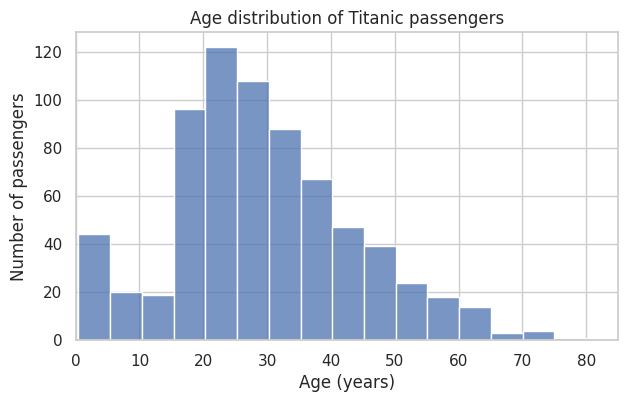

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.histplot(data=df, x="age", binwidth=5, ax=ax)

ax.set_title("Age distribution of Titanic passengers")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of passengers")
ax.set_xlim(0, 85)

Three things to notice. First, `ax.set_xlabel()` and `ax.set_ylabel()` override whatever seaborn put there. By default seaborn uses the column name, which is fine for exploration but not for a finished chart. Second, `ax.set_xlim(0, 85)` sets the left and right boundary of the x-axis explicitly so the axis starts at zero rather than at some arbitrary lower value. Third, `fig, ax = plt.subplots(figsize=(7, 4))` sets the figure size before drawing; this is the standard pattern for axes-level functions.

Two more methods you will use often: `ax.tick_params(axis="x", rotation=45)` rotates the x-tick labels when they overlap, and `ax.set_xticks([0, 20, 40, 60, 80])` controls which tick marks appear.

## Labels on figure-level charts

Figure-level functions like `sns.relplot()`, `sns.displot()`, and `sns.catplot()` return a `FacetGrid`, not an `Axes`. The `FacetGrid` has its own methods for labeling, and `figsize=` does not apply to it. Instead you use `height=` and `aspect=` to size each panel.

Text(0.5, 1.02, 'Fare by class and sex')

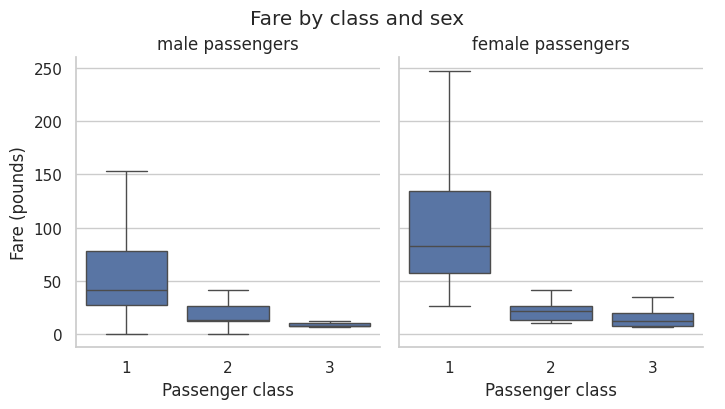

In [3]:
g = sns.catplot(
    data=df,
    x="pclass", y="fare",
    col="sex",
    kind="box",
    showfliers=False,
    height=4, aspect=0.9
)

g.set_axis_labels("Passenger class", "Fare (pounds)")
g.set_titles("{col_name} passengers")
g.figure.suptitle("Fare by class and sex", y=1.02)

`g.set_axis_labels()` sets the x and y labels on all panels at once. `g.set_titles()` controls the small title above each panel using a template string; `{col_name}` is replaced with the column value for that panel. `g.figure.suptitle()` adds a title above the entire figure. The `y=1.02` lifts the suptitle slightly so it does not overlap the panel titles.

This pattern -- `g.set_axis_labels`, `g.set_titles`, `g.figure.suptitle` -- is the same for every figure-level function.

## Themes and context

At the top of every notebook in this module, we called `sns.set_theme(style="whitegrid", context="notebook")`. Now is a good time to understand what those two arguments actually control.

`style=` controls the visual background of the chart. The five options are:

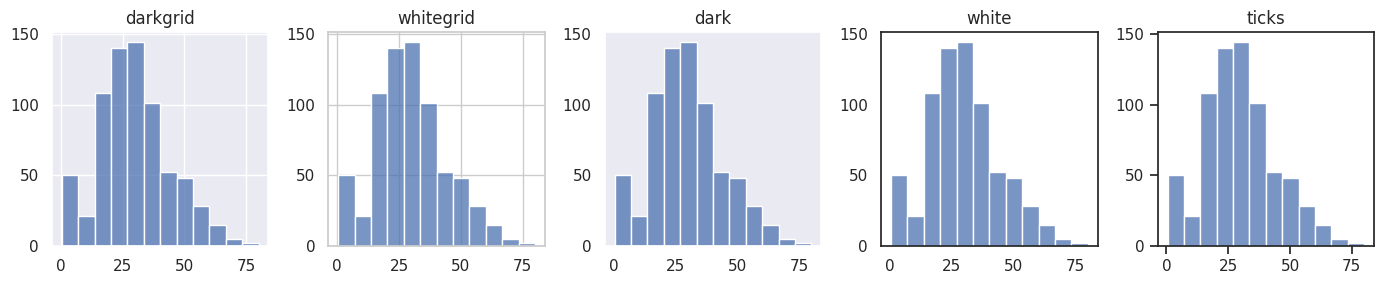

In [4]:
styles = ["darkgrid", "whitegrid", "dark", "white", "ticks"]

fig = plt.figure(figsize=(14, 3))

for i, style in enumerate(styles, 1):
    with sns.axes_style(style):
        ax = fig.add_subplot(1, 5, i)
        sns.histplot(data=df, x="age", bins=12, ax=ax)
        ax.set_title(style)
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()

`"whitegrid"` is the default for this module because the grid lines help readers trace values, and the white background reproduces cleanly on white paper. `"ticks"` is a minimal style popular for publication. `"darkgrid"` can work well in presentations but looks dark when printed.

`context=` controls the scale of text and lines. `"notebook"` is the right size for a Jupyter notebook; `"talk"` scales up for a presentation; `"paper"` scales down for a figure that will be embedded in a document with its own caption.

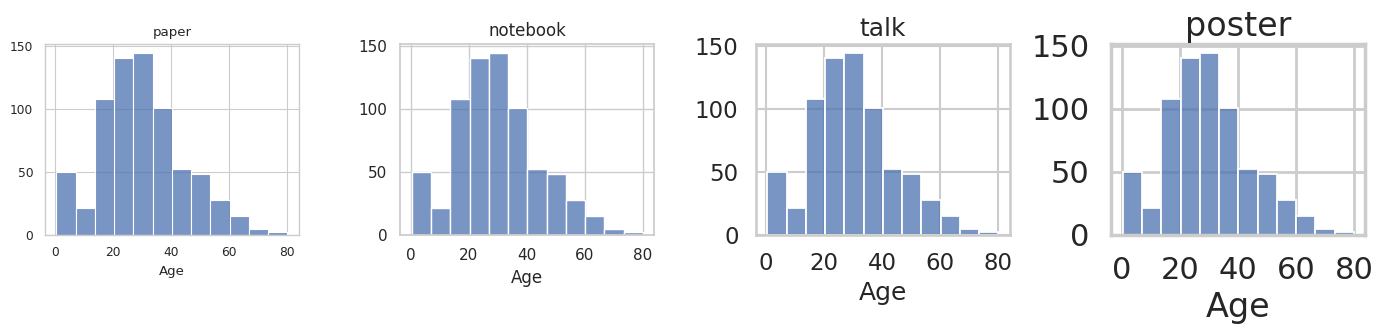

In [5]:
contexts = ["paper", "notebook", "talk", "poster"]

fig = plt.figure(figsize=(14, 3.5))

for i, ctx in enumerate(contexts, 1):
    with sns.plotting_context(ctx):
        ax = fig.add_subplot(1, 4, i)
        sns.histplot(data=df, x="age", bins=12, ax=ax)
        ax.set_title(ctx)
        ax.set_xlabel("Age")
        ax.set_ylabel("")

plt.tight_layout()

The data is identical in all four panels; only the text and line sizes change. A "notebook" chart pasted into a slide show without adjustment will look tiny because the fonts were sized for a notebook, not a projector screen.

Both `axes_style()` and `plotting_context()` work as context managers (the `with` block), which means the change is temporary and only applies to the code inside the block. Calling `sns.set_theme(style=..., context=...)` at the top of a notebook applies the change for the entire session.

## Choosing a palette

Color is a visual channel, and like any visual channel, it should map to something meaningful in the data. Seaborn organizes palettes into three families, each suited to a different kind of data.

**Qualitative palettes** are for unordered categories: sex (male, female), port of embarkation, or any grouping where the categories have no natural ordering and no midpoint. The colors should be perceptually distinct but not suggest any ordering among them. `"deep"`, `"muted"`, `"pastel"`, `"bright"`, `"dark"`, `"Set2"`, and `"colorblind"` are all qualitative.

**Sequential palettes** are for data that goes from low to high: fare, age, survival rate. The color should smoothly progress from light to dark (or a light hue to a saturated hue) to suggest "more" or "less". `"viridis"`, `"rocket"`, `"flare"`, `"mako"`, and `"YlOrRd"` are all sequential.

**Diverging palettes** are for data that has a meaningful center or zero: correlations (ranging from -1 to +1), differences from a baseline, or any quantity where both the magnitude and the direction from a midpoint matter. The center should be a neutral color (white or light gray); two hues branch out in each direction. `"vlag"`, `"coolwarm"`, `"RdBu"`, and `"bwr"` are all diverging.

Here is each family in action.

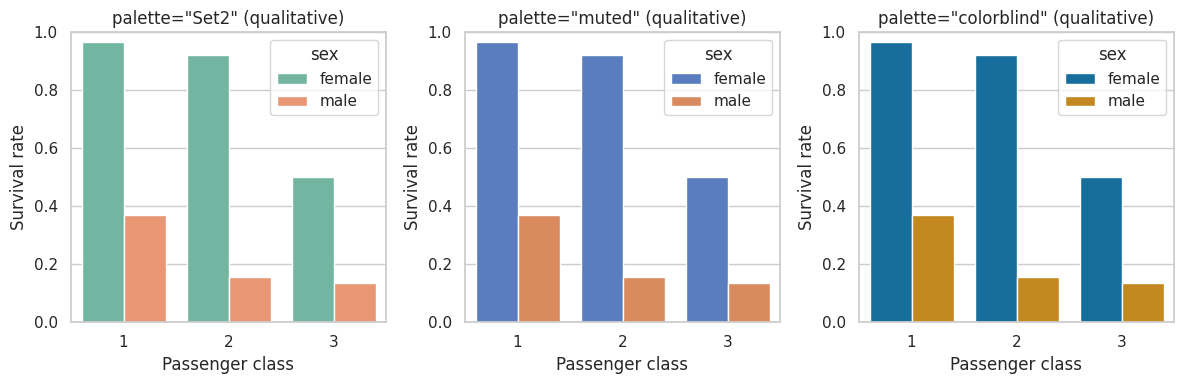

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.barplot(
    data=df, x="pclass", y="survived",
    hue="sex", order=[1, 2, 3],
    palette="Set2", errorbar=None,
    ax=axes[0]
)
axes[0].set_title('palette="Set2" (qualitative)')
axes[0].set_xlabel("Passenger class")
axes[0].set_ylabel("Survival rate")
axes[0].set_ylim(0, 1)

sns.barplot(
    data=df, x="pclass", y="survived",
    hue="sex", order=[1, 2, 3],
    palette="muted", errorbar=None,
    ax=axes[1]
)
axes[1].set_title('palette="muted" (qualitative)')
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 1)

sns.barplot(
    data=df, x="pclass", y="survived",
    hue="sex", order=[1, 2, 3],
    palette="colorblind", errorbar=None,
    ax=axes[2]
)
axes[2].set_title('palette="colorblind" (qualitative)')
axes[2].set_xlabel("Passenger class")
axes[2].set_ylabel("Survival rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()

All three palettes give each category a distinct color. The `"colorblind"` palette is specifically designed so that readers with the most common forms of color vision deficiency (red-green) can distinguish the colors. When encoding something that matters (like survival vs non-survival), `"colorblind"` is worth choosing over a visually flashier option.

Now sequential and diverging.

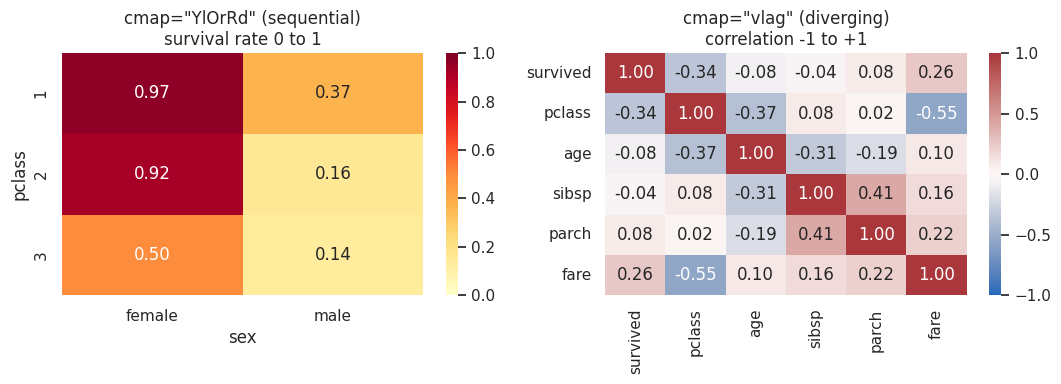

In [7]:
df_full = sns.load_dataset("titanic")
survival_grid = df_full.pivot_table(
    values="survived", index="pclass", columns="sex", aggfunc="mean"
)
corr = df.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(
    survival_grid,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    ax=axes[0]
)
axes[0].set_title('cmap="YlOrRd" (sequential)\nsurvival rate 0 to 1')

sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="vlag",
    vmin=-1, vmax=1, center=0,
    ax=axes[1]
)
axes[1].set_title('cmap="vlag" (diverging)\ncorrelation -1 to +1')

plt.tight_layout()

For survival rate, which can only be 0 to 1, a sequential palette is correct: pale yellow at the low end, dark red at the high end. There is no meaningful midpoint, so a diverging palette would be misleading. For correlations, which run from -1 to +1 with zero as a true neutral, a diverging palette is correct: blue for negative, red for positive, white at zero.

Using a sequential palette for correlations would hide the sign information. Using a diverging palette for survival rate would suggest that some survival rates are "below" something when they are all just positive proportions. The palette is not decoration; it communicates something about the nature of the data.

## Saving a figure

Once a chart is ready, you save it with `plt.savefig()` for axes-level charts or `g.savefig()` for figure-level charts. The file format is inferred from the file extension.

saved


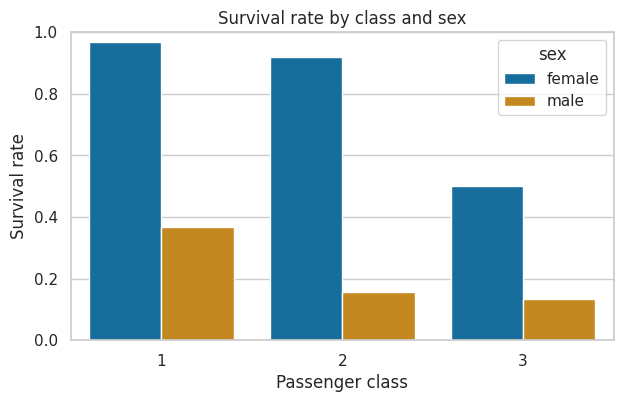

In [8]:
import os
os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=df, x="pclass", y="survived",
    hue="sex", order=[1, 2, 3],
    palette="colorblind", errorbar=None,
    ax=ax
)
ax.set_title("Survival rate by class and sex")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

plt.savefig("figures/survival_by_class.png", dpi=150, bbox_inches="tight")
print("saved")

`dpi=150` sets the resolution at 150 dots per inch, which is fine for most uses (screen, PDF embed, reports). Use `dpi=300` for print publications. `bbox_inches="tight"` trims any extra whitespace around the figure before saving; without it, the title and labels can get cut off.

Use `.png` for web and reports. Use `.pdf` or `.svg` for vector output (infinitely scalable, good for papers). Use `.jpg` only if file size is a hard constraint; JPEG compression introduces visible artifacts on charts with sharp edges.

For a figure-level chart, the call is identical but on the `FacetGrid` object.

/tmp/ipykernel_3175/1938426930.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


saved


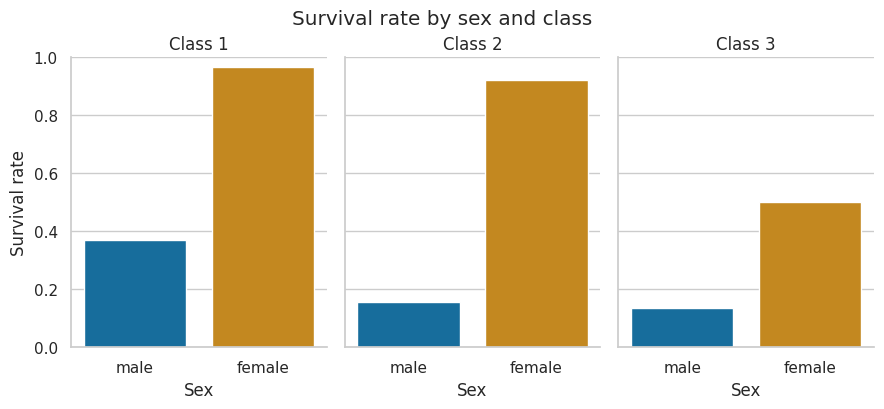

In [9]:
g = sns.catplot(
    data=df,
    x="sex", y="survived",
    col="pclass", col_order=[1, 2, 3],
    kind="bar",
    palette="colorblind",
    errorbar=None,
    height=4, aspect=0.75
)
g.set_axis_labels("Sex", "Survival rate")
g.set_titles("Class {col_name}")
g.figure.suptitle("Survival rate by sex and class", y=1.02)
for ax in g.axes.flat:
    ax.set_ylim(0, 1)

g.savefig("figures/survival_faceted.png", dpi=150, bbox_inches="tight")
print("saved")

## A worked makeover

To put all of this together, here is a before-and-after comparison. The "before" chart uses nothing but the default seaborn call with no labels or adjustments. The "after" chart applies everything from this notebook: a chosen size, a title, labeled axes, a deliberate palette, and a cleaned-up tick. Both charts contain exactly the same data.

/tmp/ipykernel_3175/3643643753.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3175/3643643753.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["First class", "Second class", "Third class"])


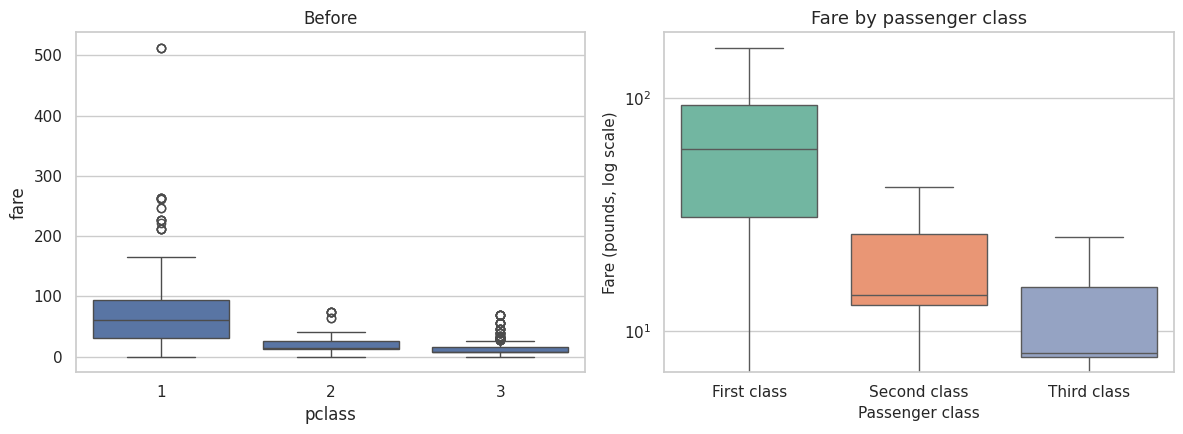

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Before
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[0])
axes[0].set_title("Before")

# After
class_order = [1, 2, 3]
palette = sns.color_palette("Set2", 3)

sns.boxplot(
    data=df,
    x="pclass", y="fare",
    order=class_order,
    palette=palette,
    showfliers=False,
    ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Fare by passenger class", fontsize=13)
axes[1].set_xlabel("Passenger class", fontsize=11)
axes[1].set_ylabel("Fare (pounds, log scale)", fontsize=11)
axes[1].set_xticklabels(["First class", "Second class", "Third class"])

plt.tight_layout()

The "before" chart is not wrong. It answers the question. But a reader has to decode the x-axis (what does 1, 2, 3 mean?), infer the y-axis units, and mentally filter out the outlier scatter that makes the boxes hard to compare.

The "after" chart answers the same question in fewer steps. The x-axis labels say what the numbers mean. The y-axis label says the units and the scale. The outliers are hidden because the question is about the typical spread, not the extremes. The log scale makes the three boxes comparable; without it, the first-class box would dominate and the third-class box would be a thin strip at the bottom.

Three calls did the most work: `ax.set_xticklabels()` to replace the numeric codes, `ax.set_yscale("log")` to correct the scale, and `showfliers=False` to remove the distraction.

## What's next

In 07.8, we take a short detour to look at pandas' built-in `.plot()` method. It is not as capable as seaborn, but it is useful for quick looks at the result of a `groupby` or `pivot_table` without having to reshape anything.